# 07 — Train Concatenated Features with Cross-Entropy + Triplet Loss

This notebook trains the concatenated-feature classifier with:

```text
total loss = cross_entropy_loss + TRIPLET_WEIGHT * batch_hard_triplet_loss
```

It saves the model, metrics, predictions, learned embeddings, confusion matrix, training curves, and optional UMAP plots.


In [12]:

from pathlib import Path
import copy
import pickle
import json

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

import matplotlib.pyplot as plt

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP is not installed. To enable UMAP, run: pip install umap-learn")


PROJECT_ROOT = Path("..")
OUTPUT_DIR = PROJECT_ROOT / "output"

SPLIT_DIR = OUTPUT_DIR / "splits"
FEATURE_DIR = OUTPUT_DIR / "features"

CONCAT_FEATURE_DIR = OUTPUT_DIR / "concat_all_features"
RESULTS_DIR = OUTPUT_DIR / "concat_all_features_triplet_results"

CONCAT_FEATURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 5e-4
PATIENCE = 8
RANDOM_SEED = 42

CHUNK_SIZE = 2048
SCALER_CHUNK_SIZE = 4096

OVERWRITE_CONCAT_FEATURES = False
OVERWRITE_SCALED_FEATURES = False

SAVE_ALL_SPLIT_EMBEDDINGS = True

USE_TRIPLET_LOSS = True
TRIPLET_MARGIN = 0.3
TRIPLET_WEIGHT = 0.2

RUN_UMAP_AFTER_TRAINING = True
UMAP_SOURCE = "test"          # "train", "val", "test", or "all"
MAX_UMAP_SAMPLES = 5000
STANDARDIZE_EMBEDDINGS_BEFORE_UMAP = True
MAX_LEGEND_CLASSES = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Device:", device)
print("Feature directory:", FEATURE_DIR)
print("Concat feature directory:", CONCAT_FEATURE_DIR)
print("Results directory:", RESULTS_DIR)


Device: cuda
Feature directory: ..\output\features
Concat feature directory: ..\output\concat_all_features
Results directory: ..\output\concat_all_features_triplet_results


In [13]:

class_names = np.load(SPLIT_DIR / "class_names.npy", allow_pickle=True)
class_names = np.asarray(class_names).astype(str)

y_train_raw = np.load(SPLIT_DIR / "y_train_idx.npy", allow_pickle=True)
y_val_raw = np.load(SPLIT_DIR / "y_val_idx.npy", allow_pickle=True)
y_test_raw = np.load(SPLIT_DIR / "y_test_idx.npy", allow_pickle=True)

class_to_idx = {name: idx for idx, name in enumerate(class_names)}


def labels_to_int(labels, split_name):
    labels = np.asarray(labels)

    if np.issubdtype(labels.dtype, np.integer):
        return labels.astype(np.int64)

    labels_str = labels.astype(str)

    missing = sorted(set(labels_str) - set(class_to_idx))
    if missing:
        raise ValueError(
            f"{split_name} contains labels not present in class_names.npy: {missing[:20]}"
        )

    return np.asarray([class_to_idx[label] for label in labels_str], dtype=np.int64)


def labels_to_names(labels):
    labels = np.asarray(labels)

    if np.issubdtype(labels.dtype, np.integer):
        return np.asarray([class_names[int(i)] for i in labels], dtype=str)

    return labels.astype(str)


y_train = labels_to_int(y_train_raw, "y_train_idx.npy")
y_val = labels_to_int(y_val_raw, "y_val_idx.npy")
y_test = labels_to_int(y_test_raw, "y_test_idx.npy")

y_train_names = labels_to_names(y_train_raw)
y_val_names = labels_to_names(y_val_raw)
y_test_names = labels_to_names(y_test_raw)

num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Train:", y_train.shape, y_train.dtype)
print("Val:", y_val.shape, y_val.dtype)
print("Test:", y_test.shape, y_test.dtype)

print("\nExample mapping:")
for i in range(min(10, len(y_train))):
    print(y_train_names[i], "->", y_train[i])


Number of classes: 32
Train: (82434,) int64
Val: (27478,) int64
Test: (27478,) int64

Example mapping:
Triclosan_05x -> 29
Mecillinam_05x -> 13
Nisin_5x -> 20
Kanamycin_2x -> 12
Kanamycin_05x -> 11
PMB_05x -> 23
Mecillinam_05x -> 13
Triclosan_05x -> 29
Triclosan_2x -> 30
PMB_05x -> 23


In [14]:

feature_folders = []

for folder in sorted(FEATURE_DIR.iterdir()):
    if not folder.is_dir():
        continue

    required_files = [
        folder / "train_features.npy",
        folder / "val_features.npy",
        folder / "test_features.npy",
    ]

    if all(path.exists() for path in required_files):
        feature_folders.append(folder)

if not feature_folders:
    raise FileNotFoundError(
        f"No valid feature folders found in {FEATURE_DIR}. "
        "Run 03_extract_pretrained_features_npy.ipynb first."
    )

print("\nDetected feature folders:")
for folder in feature_folders:
    print("-", folder.name)

rows = []

for folder in feature_folders:
    train_shape = np.load(folder / "train_features.npy", mmap_mode="r").shape
    val_shape = np.load(folder / "val_features.npy", mmap_mode="r").shape
    test_shape = np.load(folder / "test_features.npy", mmap_mode="r").shape

    rows.append({
        "feature_name": folder.name,
        "train_shape": train_shape,
        "val_shape": val_shape,
        "test_shape": test_shape,
        "feature_dim": train_shape[1],
    })

shape_df = pd.DataFrame(rows)
display(shape_df)

total_feature_dim = int(shape_df["feature_dim"].sum())
print("Total concatenated feature dimension:", total_feature_dim)



Detected feature folders:
- cytoimagenet_efficientnetb0
- densenet121
- efficientnet_b0
- mobilenet_v3_large
- resnet50
- vit_b_16


,feature_name,train_shape,val_shape,test_shape,feature_dim
0,cytoimagenet_efficientnetb0,"(82434, 5120)","(27478, 5120)","(27478, 5120)",5120
1,densenet121,"(82434, 4096)","(27478, 4096)","(27478, 4096)",4096
2,efficientnet_b0,"(82434, 5120)","(27478, 5120)","(27478, 5120)",5120
3,mobilenet_v3_large,"(82434, 3840)","(27478, 3840)","(27478, 3840)",3840
4,resnet50,"(82434, 8192)","(27478, 8192)","(27478, 8192)",8192
5,vit_b_16,"(82434, 3072)","(27478, 3072)","(27478, 3072)",3072


Total concatenated feature dimension: 29440


In [15]:

def load_split_arrays(feature_folders, split_name):
    arrays = []

    for folder in feature_folders:
        path = folder / f"{split_name}_features.npy"
        arr = np.load(path, mmap_mode="r")
        arrays.append(arr)

    return arrays


def check_split_arrays(arrays, split_name, expected_n):
    n_samples = arrays[0].shape[0]

    if n_samples != expected_n:
        raise ValueError(
            f"{split_name} feature count mismatch: features have {n_samples}, "
            f"but labels have {expected_n}."
        )

    for i, arr in enumerate(arrays):
        if arr.ndim != 2:
            raise ValueError(
                f"{split_name} array {i} must be 2D, got shape {arr.shape}."
            )

        if arr.shape[0] != n_samples:
            raise ValueError(
                f"{split_name} sample count mismatch. "
                f"Expected {n_samples}, got {arr.shape[0]} in feature index {i}."
            )

    return n_samples, int(sum(arr.shape[1] for arr in arrays))


def concatenate_split_to_memmap(
    feature_folders,
    split_name,
    labels,
    out_file,
    overwrite=False,
    chunk_size=CHUNK_SIZE,
):
    out_file = Path(out_file)

    if out_file.exists() and not overwrite:
        print(f"Using existing concatenated {split_name} file:", out_file)
        return np.load(out_file, mmap_mode="r")

    arrays = load_split_arrays(feature_folders, split_name)

    n_samples, total_dim = check_split_arrays(
        arrays,
        split_name=split_name,
        expected_n=len(labels),
    )

    if out_file.exists():
        out_file.unlink()

    out = np.lib.format.open_memmap(
        out_file,
        mode="w+",
        dtype=np.float32,
        shape=(n_samples, total_dim),
    )

    for start in range(0, n_samples, chunk_size):
        end = min(start + chunk_size, n_samples)

        chunks = [
            np.asarray(arr[start:end], dtype=np.float32)
            for arr in arrays
        ]

        out[start:end] = np.concatenate(chunks, axis=1)

        if end % (chunk_size * 10) == 0 or end == n_samples:
            print(f"  {split_name}: concatenated {end}/{n_samples}")

    out.flush()
    del out

    return np.load(out_file, mmap_mode="r")


X_train_concat = concatenate_split_to_memmap(
    feature_folders,
    split_name="train",
    labels=y_train,
    out_file=CONCAT_FEATURE_DIR / "train_concat_features.npy",
    overwrite=OVERWRITE_CONCAT_FEATURES,
)

X_val_concat = concatenate_split_to_memmap(
    feature_folders,
    split_name="val",
    labels=y_val,
    out_file=CONCAT_FEATURE_DIR / "val_concat_features.npy",
    overwrite=OVERWRITE_CONCAT_FEATURES,
)

X_test_concat = concatenate_split_to_memmap(
    feature_folders,
    split_name="test",
    labels=y_test,
    out_file=CONCAT_FEATURE_DIR / "test_concat_features.npy",
    overwrite=OVERWRITE_CONCAT_FEATURES,
)

print("\nConcatenated feature shapes:")
print("Train:", X_train_concat.shape)
print("Val:", X_val_concat.shape)
print("Test:", X_test_concat.shape)


Using existing concatenated train file: ..\output\concat_all_features\train_concat_features.npy
Using existing concatenated val file: ..\output\concat_all_features\val_concat_features.npy
Using existing concatenated test file: ..\output\concat_all_features\test_concat_features.npy

Concatenated feature shapes:
Train: (82434, 29440)
Val: (27478, 29440)
Test: (27478, 29440)


In [16]:

def iter_feature_chunks(X, chunk_size=SCALER_CHUNK_SIZE):
    for start in range(0, len(X), chunk_size):
        end = min(start + chunk_size, len(X))
        yield start, end, np.asarray(X[start:end], dtype=np.float32)


def fit_scaler_chunked(X_train_raw):
    scaler = StandardScaler()

    for start, end, chunk in iter_feature_chunks(X_train_raw):
        scaler.partial_fit(chunk)

        if end % (SCALER_CHUNK_SIZE * 10) == 0 or end == len(X_train_raw):
            print(f"  scaler fitted on {end}/{len(X_train_raw)} samples")

    return scaler


def transform_to_memmap(X_raw, scaler, out_file, overwrite=False):
    out_file = Path(out_file)

    if out_file.exists() and not overwrite:
        print("Using existing scaled file:", out_file)
        return np.load(out_file, mmap_mode="r")

    if out_file.exists():
        out_file.unlink()

    out = np.lib.format.open_memmap(
        out_file,
        mode="w+",
        dtype=np.float32,
        shape=X_raw.shape,
    )

    for start, end, chunk in iter_feature_chunks(X_raw):
        out[start:end] = scaler.transform(chunk).astype(np.float32)

        if end % (SCALER_CHUNK_SIZE * 10) == 0 or end == len(X_raw):
            print(f"  transformed {end}/{len(X_raw)} samples")

    out.flush()
    del out

    return np.load(out_file, mmap_mode="r")


scaler = fit_scaler_chunked(X_train_concat)

with open(RESULTS_DIR / "concat_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

X_train_scaled = transform_to_memmap(
    X_train_concat,
    scaler,
    RESULTS_DIR / "train_concat_features_scaled.npy",
    overwrite=OVERWRITE_SCALED_FEATURES,
)

X_val_scaled = transform_to_memmap(
    X_val_concat,
    scaler,
    RESULTS_DIR / "val_concat_features_scaled.npy",
    overwrite=OVERWRITE_SCALED_FEATURES,
)

X_test_scaled = transform_to_memmap(
    X_test_concat,
    scaler,
    RESULTS_DIR / "test_concat_features_scaled.npy",
    overwrite=OVERWRITE_SCALED_FEATURES,
)

print("\nScaled feature shapes:")
print("Train:", X_train_scaled.shape)
print("Val:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)


  scaler fitted on 40960/82434 samples
  scaler fitted on 81920/82434 samples
  scaler fitted on 82434/82434 samples
Using existing scaled file: ..\output\concat_all_features_triplet_results\train_concat_features_scaled.npy
Using existing scaled file: ..\output\concat_all_features_triplet_results\val_concat_features_scaled.npy
Using existing scaled file: ..\output\concat_all_features_triplet_results\test_concat_features_scaled.npy

Scaled feature shapes:
Train: (82434, 29440)
Val: (27478, 29440)
Test: (27478, 29440)


In [17]:

class FeatureDataset(Dataset):
    def __init__(self, X_features, y_idx):
        self.X = X_features
        self.y = np.asarray(y_idx, dtype=np.int64)

        if len(self.X) != len(self.y):
            raise ValueError(
                f"Feature/label length mismatch: X has {len(self.X)} samples, "
                f"but y has {len(self.y)} labels."
            )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = np.asarray(self.X[idx], dtype=np.float32)
        x = np.ascontiguousarray(x)
        y = int(self.y[idx])
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


class ConcatFeatureClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.feature_layers = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.3),
        )

        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        embedding = self.feature_layers(x)
        logits = self.classifier(embedding)
        return logits

    def extract_embedding(self, x):
        return self.feature_layers(x)


def batch_hard_triplet_loss(embeddings, labels, margin=0.3):
    """
    Batch-hard triplet loss using cosine distance.

    For each anchor:
    - hardest positive = farthest sample with the same label
    - hardest negative = closest sample with a different label

    Returns 0 if a batch has no valid positive pairs.
    """

    embeddings = F.normalize(embeddings, p=2, dim=1)

    similarity = embeddings @ embeddings.T
    distance = 1.0 - similarity

    labels = labels.view(-1, 1)

    positive_mask = labels.eq(labels.T)
    negative_mask = ~positive_mask

    positive_mask.fill_diagonal_(False)

    valid_anchor_mask = positive_mask.any(dim=1)

    if valid_anchor_mask.sum() == 0:
        return embeddings.new_tensor(0.0)

    positive_distances = distance.clone()
    positive_distances[~positive_mask] = -1.0
    hardest_positive = positive_distances.max(dim=1).values

    negative_distances = distance.clone()
    negative_distances[~negative_mask] = 2.0
    hardest_negative = negative_distances.min(dim=1).values

    loss = F.relu(hardest_positive - hardest_negative + margin)
    loss = loss[valid_anchor_mask].mean()

    return loss


train_dataset = FeatureDataset(X_train_scaled, y_train)
val_dataset = FeatureDataset(X_val_scaled, y_val)
test_dataset = FeatureDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_eval_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

input_dim = X_train_scaled.shape[1]

model = ConcatFeatureClassifier(
    input_dim=input_dim,
    num_classes=num_classes,
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print(model)
print("Input dimension:", input_dim)
print("Use triplet loss:", USE_TRIPLET_LOSS)
print("Triplet margin:", TRIPLET_MARGIN)
print("Triplet weight:", TRIPLET_WEIGHT)


ConcatFeatureClassifier(
  (feature_layers): Sequential(
    (0): Linear(in_features=29440, out_features=1024, bias=True)
    (1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=1024, out_features=256, bias=True)
    (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.3, inplace=False)
  )
  (classifier): Linear(in_features=128, out_features=32, bias=True)
)
Input dimension: 29440
Use triplet loss: True
Triplet margin: 0.3
Triplet weight: 0.2


In [ ]:

def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_ce_loss = 0.0
    total_triplet_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for batch_features, batch_labels in loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            if is_train:
                optimizer.zero_grad()

            embeddings = model.extract_embedding(batch_features)
            logits = model.classifier(embeddings)

            ce_loss = criterion(logits, batch_labels)

            if USE_TRIPLET_LOSS:
                triplet_loss = batch_hard_triplet_loss(
                    embeddings,
                    batch_labels,
                    margin=TRIPLET_MARGIN,
                )
                loss = ce_loss + TRIPLET_WEIGHT * triplet_loss
            else:
                triplet_loss = torch.tensor(0.0, device=device)
                loss = ce_loss

            if is_train:
                loss.backward()
                optimizer.step()

            batch_size = batch_features.size(0)

            total_loss += loss.item() * batch_size
            total_ce_loss += ce_loss.item() * batch_size
            total_triplet_loss += triplet_loss.item() * batch_size

            preds = torch.argmax(logits, dim=1)
            correct += (preds == batch_labels).sum().item()
            total += batch_labels.size(0)

    return {
        "loss": total_loss / total,
        "ce_loss": total_ce_loss / total,
        "triplet_loss": total_triplet_loss / total,
        "acc": correct / total,
    }


history = []
best_val_acc = -1.0
best_state = None
best_epoch = -1
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    train_metrics = run_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
    )

    val_metrics = run_one_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
    )

    row = {
        "epoch": epoch + 1,

        "train_loss": train_metrics["loss"],
        "train_ce_loss": train_metrics["ce_loss"],
        "train_triplet_loss": train_metrics["triplet_loss"],
        "train_acc": train_metrics["acc"],

        "val_loss": val_metrics["loss"],
        "val_ce_loss": val_metrics["ce_loss"],
        "val_triplet_loss": val_metrics["triplet_loss"],
        "val_acc": val_metrics["acc"],
    }

    history.append(row)

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] "
        f"Train Loss: {row['train_loss']:.4f} "
        f"CE: {row['train_ce_loss']:.4f} "
        f"Triplet: {row['train_triplet_loss']:.4f} "
        f"Train Acc: {row['train_acc']:.4f} "
        f"Val Loss: {row['val_loss']:.4f} "
        f"Val CE: {row['val_ce_loss']:.4f} "
        f"Val Triplet: {row['val_triplet_loss']:.4f} "
        f"Val Acc: {row['val_acc']:.4f}"
    )

    if row["val_acc"] > best_val_acc:
        best_val_acc = row["val_acc"]
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / "training_history.csv", index=False)

if best_state is not None:
    model.load_state_dict(best_state)

print("\nBest epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)


Epoch [01/50] Train Loss: 1.5686 CE: 1.4625 Triplet: 0.5306 Train Acc: 0.5101 Val Loss: 0.9302 Val CE: 0.8438 Val Triplet: 0.4320 Val Acc: 0.7053
Epoch [02/50] Train Loss: 0.9673 CE: 0.8767 Triplet: 0.4527 Train Acc: 0.6947 Val Loss: 0.7988 Val CE: 0.7199 Val Triplet: 0.3948 Val Acc: 0.7420
Epoch [03/50] Train Loss: 0.8070 CE: 0.7214 Triplet: 0.4280 Train Acc: 0.7448 Val Loss: 0.6922 Val CE: 0.6164 Val Triplet: 0.3789 Val Acc: 0.7835
Epoch [04/50] Train Loss: 0.7061 CE: 0.6237 Triplet: 0.4123 Train Acc: 0.7798 Val Loss: 0.6593 Val CE: 0.5863 Val Triplet: 0.3653 Val Acc: 0.7922
Epoch [05/50] Train Loss: 0.6341 CE: 0.5545 Triplet: 0.3980 Train Acc: 0.8047 Val Loss: 0.6266 Val CE: 0.5552 Val Triplet: 0.3570 Val Acc: 0.8044
Epoch [06/50] Train Loss: 0.5754 CE: 0.4979 Triplet: 0.3876 Train Acc: 0.8243 Val Loss: 0.6314 Val CE: 0.5612 Val Triplet: 0.3508 Val Acc: 0.8059
Epoch [07/50] Train Loss: 0.5221 CE: 0.4467 Triplet: 0.3767 Train Acc: 0.8418 Val Loss: 0.6295 Val CE: 0.5592 Val Triplet: 0

In [ ]:

def collect_embeddings_predictions(model, loader, split_name, save_dir):
    model.eval()

    save_dir = Path(save_dir)
    embeddings_path = save_dir / f"{split_name}_concat_triplet_classifier_embeddings.npy"
    logits_path = save_dir / f"{split_name}_concat_triplet_classifier_logits.npy"

    embedding_memmap = None
    logits_memmap = None

    all_preds = []
    all_labels = []
    write_start = 0

    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features = batch_features.to(device)

            embeddings = model.extract_embedding(batch_features)
            logits = model.classifier(embeddings)

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            labels = batch_labels.numpy()

            embeddings = embeddings.cpu().numpy().astype(np.float32)
            logits = logits.cpu().numpy().astype(np.float32)

            if embedding_memmap is None:
                if embeddings_path.exists():
                    embeddings_path.unlink()
                if logits_path.exists():
                    logits_path.unlink()

                embedding_memmap = np.lib.format.open_memmap(
                    embeddings_path,
                    mode="w+",
                    dtype=np.float32,
                    shape=(len(loader.dataset), embeddings.shape[1]),
                )

                logits_memmap = np.lib.format.open_memmap(
                    logits_path,
                    mode="w+",
                    dtype=np.float32,
                    shape=(len(loader.dataset), logits.shape[1]),
                )

            write_end = write_start + embeddings.shape[0]
            embedding_memmap[write_start:write_end] = embeddings
            logits_memmap[write_start:write_end] = logits
            write_start = write_end

            all_preds.extend(preds)
            all_labels.extend(labels)

    if embedding_memmap is not None:
        embedding_memmap.flush()
        del embedding_memmap

    if logits_memmap is not None:
        logits_memmap.flush()
        del logits_memmap

    pred_idx = np.asarray(all_preds, dtype=np.int64)
    true_idx = np.asarray(all_labels, dtype=np.int64)

    pred_names = np.asarray([class_names[i] for i in pred_idx])
    true_names = np.asarray([class_names[i] for i in true_idx])

    np.save(save_dir / f"{split_name}_concat_triplet_predictions_idx.npy", pred_idx)
    np.save(save_dir / f"{split_name}_concat_triplet_predictions_names.npy", pred_names)
    np.save(save_dir / f"{split_name}_concat_triplet_true_idx.npy", true_idx)
    np.save(save_dir / f"{split_name}_concat_triplet_true_names.npy", true_names)

    return pred_idx, true_idx


if SAVE_ALL_SPLIT_EMBEDDINGS:
    train_preds, train_labels = collect_embeddings_predictions(
        model,
        train_eval_loader,
        split_name="train",
        save_dir=RESULTS_DIR,
    )

    val_preds, val_labels = collect_embeddings_predictions(
        model,
        val_loader,
        split_name="val",
        save_dir=RESULTS_DIR,
    )

test_preds, test_labels = collect_embeddings_predictions(
    model,
    test_loader,
    split_name="test",
    save_dir=RESULTS_DIR,
)

test_acc = accuracy_score(test_labels, test_preds)
macro_f1 = f1_score(test_labels, test_preds, average="macro", zero_division=0)
weighted_f1 = f1_score(test_labels, test_preds, average="weighted", zero_division=0)

report_text = classification_report(
    test_labels,
    test_preds,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0,
)

cm = confusion_matrix(
    test_labels,
    test_preds,
    labels=np.arange(num_classes),
)

np.save(RESULTS_DIR / "concat_triplet_confusion_matrix.npy", cm)

with open(RESULTS_DIR / "concat_triplet_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

summary = {
    "feature_name": "concat_all_features_triplet",
    "input_dim": int(input_dim),
    "num_classes": int(num_classes),
    "best_epoch": int(best_epoch),
    "best_val_acc": float(best_val_acc),
    "test_acc": float(test_acc),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "use_triplet_loss": bool(USE_TRIPLET_LOSS),
    "triplet_margin": float(TRIPLET_MARGIN),
    "triplet_weight": float(TRIPLET_WEIGHT),
    "feature_folders": [folder.name for folder in feature_folders],
}

pd.DataFrame([summary]).to_csv(RESULTS_DIR / "concat_triplet_summary.csv", index=False)

with open(RESULTS_DIR / "concat_triplet_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

torch.save(
    {
        "feature_name": "concat_all_features_triplet",
        "input_dim": input_dim,
        "num_classes": num_classes,
        "class_names": class_names.tolist(),
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "use_triplet_loss": USE_TRIPLET_LOSS,
        "triplet_margin": TRIPLET_MARGIN,
        "triplet_weight": TRIPLET_WEIGHT,
        "feature_folders": [folder.name for folder in feature_folders],
        "model_state_dict": model.state_dict(),
    },
    RESULTS_DIR / "best_concat_triplet_classifier.pt",
)

print("\nConcat feature + triplet test results")
print("=" * 80)
print("Input dimension:", input_dim)
print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)
print("Test accuracy:", test_acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("\nClassification report:")
print(report_text)

display(pd.DataFrame([summary]))



Concat feature + triplet test results
Input dimension: 29440
Best epoch: 34
Best validation accuracy: 0.8365965499672465
Test accuracy: 0.8381614382415022
Macro F1: 0.8566335241818892
Weighted F1: 0.8389340318740922

Classification report:
                     precision    recall  f1-score   support

            A22_05x       0.84      0.78      0.81      1305
             A22_2x       0.72      0.74      0.73      1193
     Ampicillin_05x       0.76      0.83      0.79       372
      Ampicillin_2x       0.81      0.83      0.82       381
              Blank       0.00      0.00      0.00         0
Chloramphenicol_05x       0.85      0.74      0.79       361
 Chloramphenicol_2x       0.77      0.88      0.83       460
            Control       0.94      0.95      0.94      2263
     Gramacidin_05x       0.91      0.83      0.86      1247
      Gramacidin_2x       0.97      0.92      0.94       336
      Gramacidin_5x       0.99      0.92      0.95       295
      Kanamycin_05x       

,feature_name,input_dim,num_classes,best_epoch,best_val_acc,test_acc,macro_f1,weighted_f1,use_triplet_loss,triplet_margin,triplet_weight,feature_folders
0,concat_all_features_triplet,29440,32,34,0.836597,0.838161,0.856634,0.838934,True,0.3,0.2,"[cytoimagenet_efficientnetb0, densenet121, eff..."


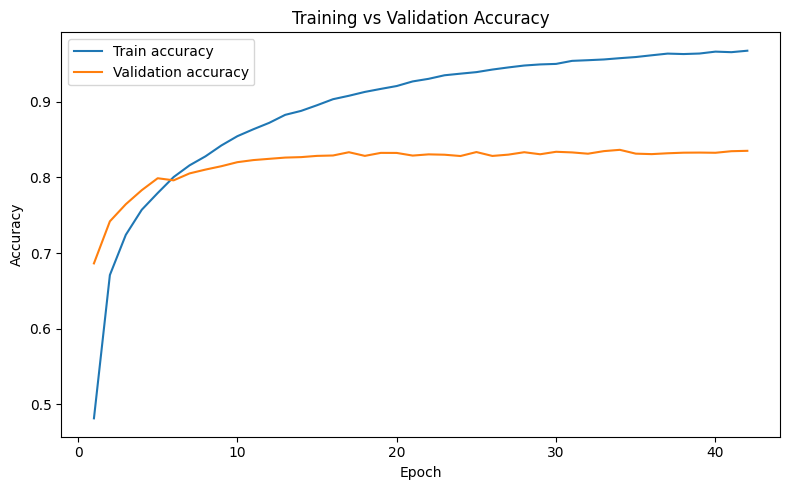

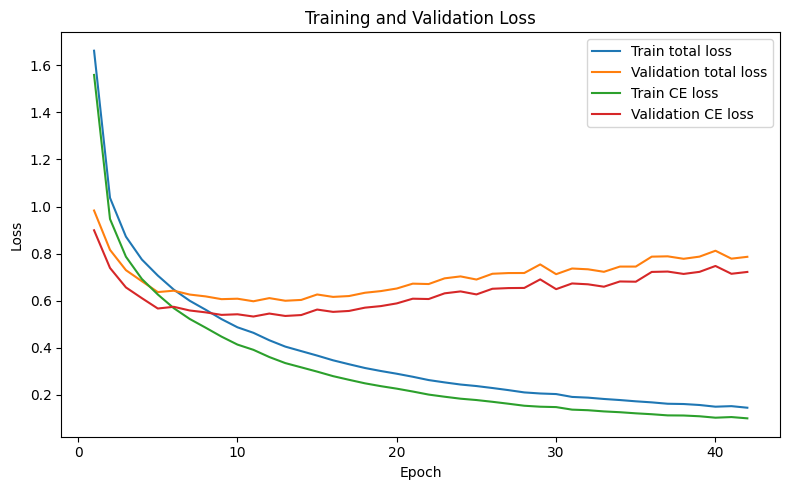

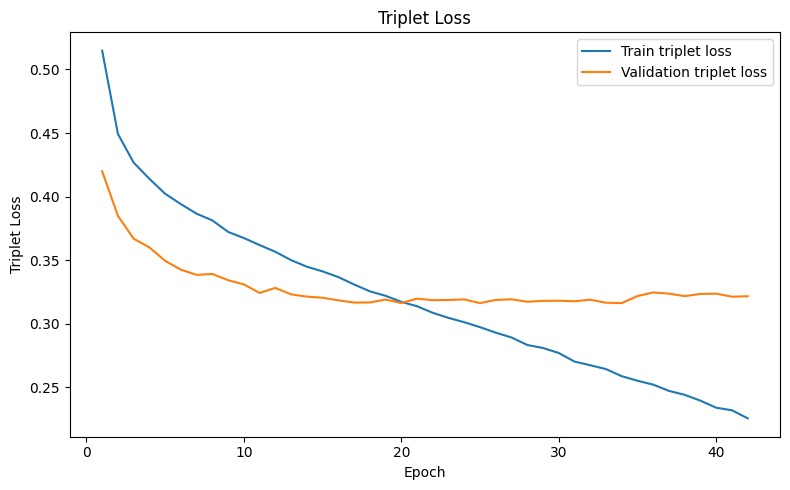

In [ ]:

history_df = pd.read_csv(RESULTS_DIR / "training_history.csv")

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "triplet_training_validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train total loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation total loss")
plt.plot(history_df["epoch"], history_df["train_ce_loss"], label="Train CE loss")
plt.plot(history_df["epoch"], history_df["val_ce_loss"], label="Validation CE loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "triplet_training_validation_loss.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_triplet_loss"], label="Train triplet loss")
plt.plot(history_df["epoch"], history_df["val_triplet_loss"], label="Validation triplet loss")
plt.xlabel("Epoch")
plt.ylabel("Triplet Loss")
plt.title("Triplet Loss")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "triplet_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


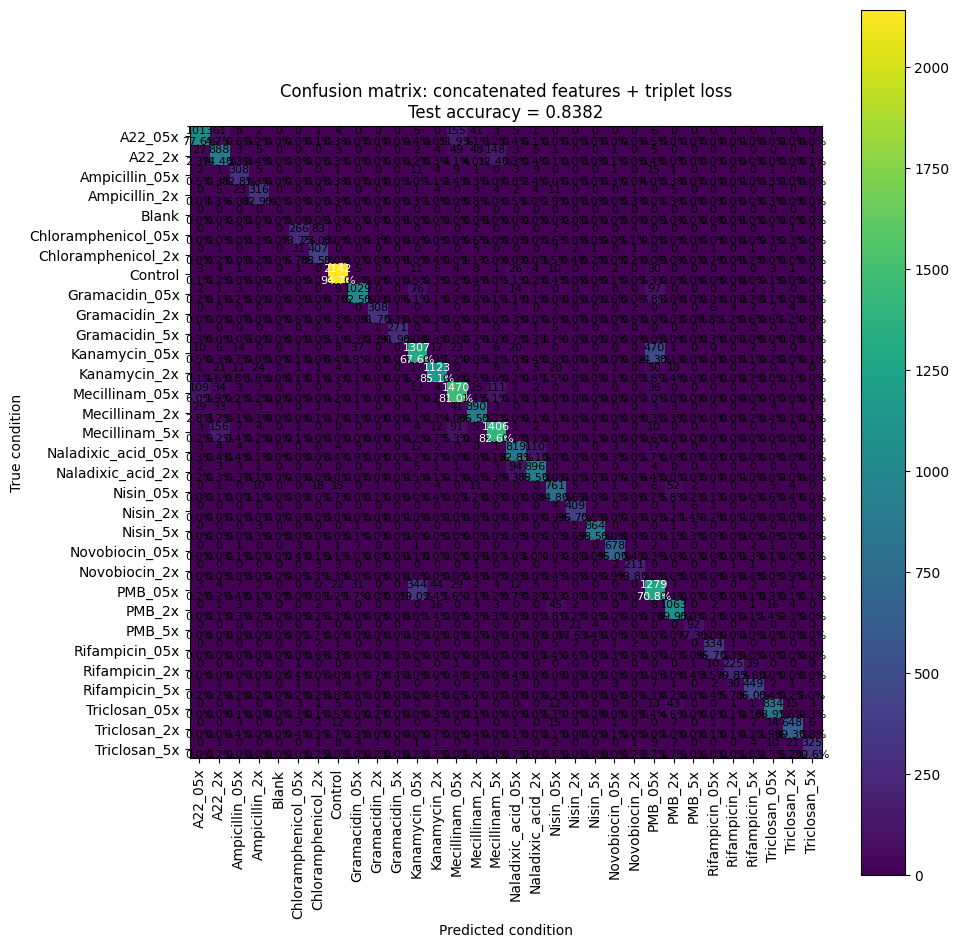

In [ ]:

plt.figure(figsize=(10, 10))
plt.imshow(cm)

plt.title(
    f"Confusion matrix: concatenated features + triplet loss\n"
    f"Test accuracy = {test_acc:.4f}"
)

plt.xlabel("Predicted condition")
plt.ylabel("True condition")
plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.colorbar()

row_sums = cm.sum(axis=1, keepdims=True)
cm_percent = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0,
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = f"{cm[i, j]}\n{cm_percent[i, j] * 100:.1f}%"

        plt.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=8,
        )

plt.tight_layout()
plt.savefig(RESULTS_DIR / "concat_triplet_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()



UMAP input shape: (5000, 128)
Number of labels: 31
Applied StandardScaler before UMAP.


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


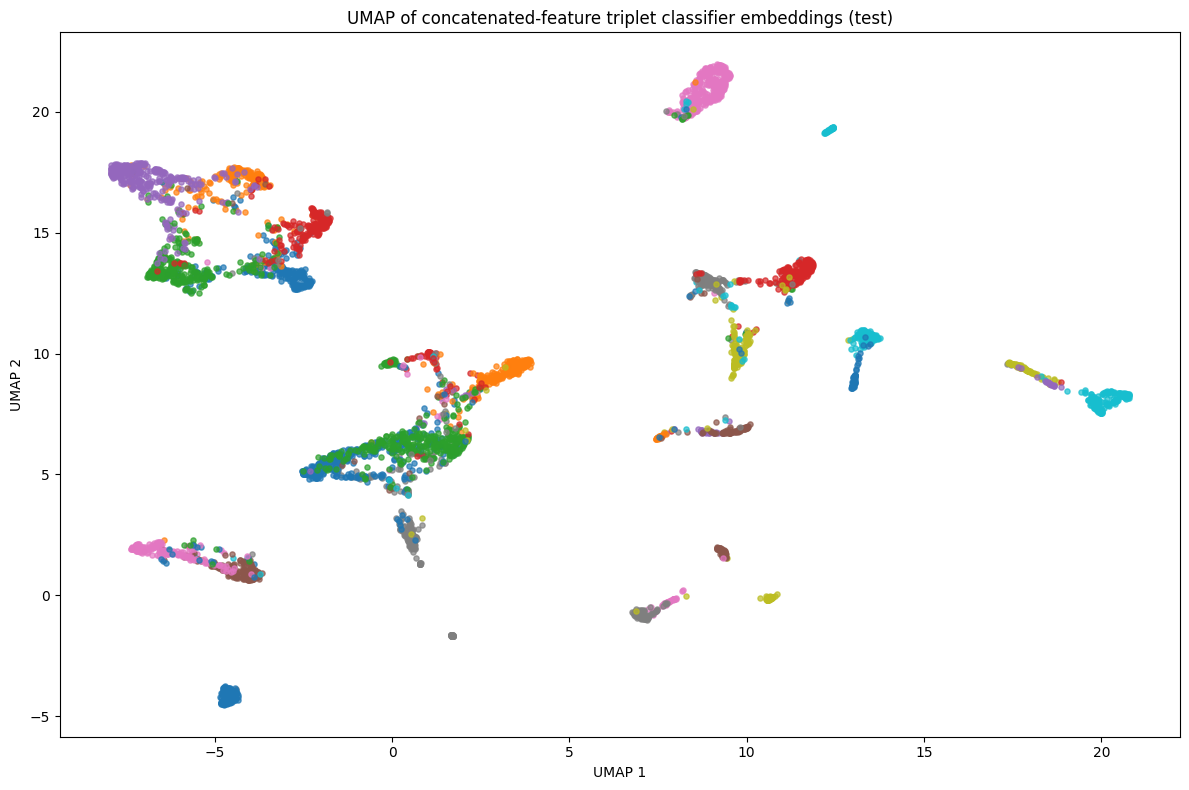

In [ ]:

def random_sample_indices(n_samples, max_samples, seed=RANDOM_SEED):
    if n_samples <= max_samples:
        return np.arange(n_samples)

    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n_samples, size=max_samples, replace=False))


def proportional_sample_counts(sizes, max_total):
    total = int(np.sum(sizes))

    if total <= max_total:
        return list(sizes)

    proportions = np.asarray(sizes, dtype=float) / total
    counts = np.floor(proportions * max_total).astype(int)
    counts = np.maximum(counts, 1)

    while counts.sum() > max_total:
        idx = np.argmax(counts)
        if counts[idx] > 1:
            counts[idx] -= 1
        else:
            break

    while counts.sum() < max_total:
        remaining = np.asarray(sizes) - counts
        idx = np.argmax(remaining)
        if remaining[idx] > 0:
            counts[idx] += 1
        else:
            break

    return counts.tolist()


def load_umap_data(results_dir, source="test", max_samples=5000):
    if source not in {"train", "val", "test", "all"}:
        raise ValueError("UMAP_SOURCE must be one of: train, val, test, all")

    if source in {"train", "val", "test"}:
        emb = np.load(
            results_dir / f"{source}_concat_triplet_classifier_embeddings.npy",
            mmap_mode="r",
        )
        labels = np.load(
            results_dir / f"{source}_concat_triplet_true_names.npy",
            allow_pickle=True,
        )

        idx = random_sample_indices(len(labels), max_samples)

        X = np.asarray(emb[idx], dtype=np.float32)
        y = np.asarray(labels[idx]).astype(str)
        splits = np.array([source] * len(idx))

        return X, y, splits

    split_names = ["train", "val", "test"]
    sizes = []

    for split in split_names:
        labels = np.load(
            results_dir / f"{split}_concat_triplet_true_names.npy",
            allow_pickle=True,
        )
        sizes.append(len(labels))

    counts = proportional_sample_counts(sizes, max_samples)

    X_list = []
    y_list = []
    split_list = []

    for split, count in zip(split_names, counts):
        emb = np.load(
            results_dir / f"{split}_concat_triplet_classifier_embeddings.npy",
            mmap_mode="r",
        )
        labels = np.load(
            results_dir / f"{split}_concat_triplet_true_names.npy",
            allow_pickle=True,
        )

        idx = random_sample_indices(len(labels), count)

        X_list.append(np.asarray(emb[idx], dtype=np.float32))
        y_list.append(np.asarray(labels[idx]).astype(str))
        split_list.append(np.array([split] * len(idx)))

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    splits = np.concatenate(split_list, axis=0)

    return X, y, splits


def plot_umap_by_label(coords, labels, title, out_file):
    labels = np.asarray(labels).astype(str)
    unique_labels = np.unique(labels)

    plt.figure(figsize=(12, 8))

    for label in unique_labels:
        mask = labels == label

        plt.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=14,
            alpha=0.7,
            label=label,
        )

    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")

    if len(unique_labels) <= MAX_LEGEND_CLASSES:
        plt.legend(
            title="Condition",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            fontsize=8,
            markerscale=1.8,
        )

    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_umap_by_split(coords, splits, title, out_file):
    splits = np.asarray(splits)
    unique_splits = np.unique(splits)

    plt.figure(figsize=(10, 8))

    for split in unique_splits:
        mask = splits == split

        plt.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=14,
            alpha=0.7,
            label=str(split),
        )

    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


if RUN_UMAP_AFTER_TRAINING:
    if not HAS_UMAP:
        print("Skipping UMAP because umap-learn is not installed.")
    else:
        X_umap, y_umap, split_umap = load_umap_data(
            RESULTS_DIR,
            source=UMAP_SOURCE,
            max_samples=MAX_UMAP_SAMPLES,
        )

        print("\nUMAP input shape:", X_umap.shape)
        print("Number of labels:", len(np.unique(y_umap)))

        if STANDARDIZE_EMBEDDINGS_BEFORE_UMAP:
            X_umap = StandardScaler().fit_transform(X_umap)
            print("Applied StandardScaler before UMAP.")

        n_neighbors = min(15, len(X_umap) - 1)
        n_neighbors = max(2, n_neighbors)

        reducer = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=0.1,
            n_components=2,
            metric="euclidean",
            random_state=RANDOM_SEED,
        )

        umap_coords = reducer.fit_transform(X_umap)

        np.save(
            RESULTS_DIR / f"concat_triplet_umap_{UMAP_SOURCE}_coords.npy",
            umap_coords,
        )

        umap_df = pd.DataFrame({
            "split": split_umap,
            "label": y_umap,
            "umap_x": umap_coords[:, 0],
            "umap_y": umap_coords[:, 1],
        })

        umap_df.to_csv(
            RESULTS_DIR / f"concat_triplet_umap_{UMAP_SOURCE}_coords.csv",
            index=False,
        )

        plot_umap_by_label(
            umap_coords,
            y_umap,
            title=f"UMAP of concatenated-feature triplet classifier embeddings ({UMAP_SOURCE})",
            out_file=RESULTS_DIR / f"concat_triplet_umap_{UMAP_SOURCE}_by_label.png",
        )

        if UMAP_SOURCE == "all":
            plot_umap_by_split(
                umap_coords,
                split_umap,
                title="UMAP of concatenated-feature triplet embeddings colored by split",
                out_file=RESULTS_DIR / "concat_triplet_umap_all_by_split.png",
            )
